In [1]:
!pip install nltk spacy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     - -------------------------------------- 0.5/12.8 MB 1.1 MB/s eta 0:00:11
     - -------------------------------------- 0.5/12.8 MB 1.1 MB/s eta 0:00:11
     -- ------------------------------------ 0.8/12.8 MB 726.0 kB/s eta 0:00:17
     -- ------------------------------------ 0.8/12.8 MB 726.0 kB/s eta 0:00:17
     --- ----------------------------------- 1.0/12.8 MB 689.2 kB/s eta 0:00:18
     --- ----------------------------------- 1.0/12.8 MB 689.2 kB/s eta 0:00:18
     --- ----------------------------------- 1.0/12.8 MB 689.2 kB/s eta 0:00:18
     --- ----------------------------------- 1.3/12.8 MB 652.1 kB/s eta 0:00:18
     ---- ---------------------------------- 1.6/12.8 MB 708.9 kB/s eta 0:

In [2]:
import pandas as pd
import numpy as np
import nltk
import spacy

from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from scipy.sparse import hstack
import matplotlib.pyplot as plt

In [3]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lanovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Lanovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lanovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Lanovo\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\Lanovo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


True

In [4]:
real = pd.read_csv("True.csv")
fake = pd.read_csv("Fake.csv")

print(real.shape)
print(fake.shape)

(21417, 4)
(23481, 4)


In [5]:
real = real.sample(3000, random_state=42)
fake = fake.sample(3000, random_state=42)
real["label"] = 1
fake["label"] = 0
df = pd.concat([real, fake]).reset_index(drop=True)
df.head()

,title,text,subject,date,label
0,Europe rights watchdog says Turkey's emergency...,BRUSSELS (Reuters) - A leading European rights...,worldnews,"October 6, 2017",1
1,Exclusive: Trump targets illegal immigrants wh...,"(Reuters) - In September 2014, Gilberto Velasq...",politicsNews,"June 9, 2017",1
2,"At G20 summit, Trump pledges $639 million in a...",HAMBURG (Reuters) - U.S. President Donald Trum...,politicsNews,"July 8, 2017",1
3,Ex-Christie associates lose bid for new trial ...,NEW YORK (Reuters) - A federal judge rejected ...,politicsNews,"March 2, 2017",1
4,Young blacks more open to Bernie Sanders' Whit...,"ORANGEBURG, S.C. (Reuters) - If Democratic hop...",politicsNews,"February 12, 2016",1


In [6]:
df["sentences"] = df["text"].apply(sent_tokenize)
df["tokens"] = df["text"].apply(word_tokenize)

In [7]:
stop_words = set(stopwords.words('english'))
pronouns = {"i","we","they","he","she","you","us"}
filtered_stopwords = stop_words - pronouns

In [8]:
lemmatizer = WordNetLemmatizer()

def clean_tokens(tokens):
    return [lemmatizer.lemmatize(word.lower())
            for word in tokens
            if word.lower() not in filtered_stopwords]

df["clean_tokens"] = df["tokens"].apply(clean_tokens)

In [9]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\Lanovo\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [10]:
df["pos_tags"] = df["clean_tokens"].apply(pos_tag)

In [11]:
def superlative_ratio(pos_tags):
    count = sum(1 for word, tag in pos_tags if tag in ["JJS","RBS"])
    return count / len(pos_tags) if len(pos_tags)>0 else 0
df["superlative_ratio"] = df["pos_tags"].apply(superlative_ratio)

In [12]:
def proper_noun_ratio(pos_tags):
    count = sum(1 for word, tag in pos_tags if tag == "NNP")
    return count / len(pos_tags) if len(pos_tags)>0 else 0
df["proper_noun_ratio"] = df["pos_tags"].apply(proper_noun_ratio)

In [13]:
def pronoun_ratio(pos_tags):
    first = sum(1 for word, tag in pos_tags if word.lower() in ["i","we"])
    third = sum(1 for word, tag in pos_tags if word.lower() in ["he","she","they"])
    return first / (third+1)

df["pronoun_ratio"] = df["pos_tags"].apply(pronoun_ratio)

In [14]:
df["avg_sentence_length"] = df["sentences"].apply(
    lambda sents: (
        sum(len(word_tokenize(s)) for s in sents) / len(sents)
        if len(sents) > 0 else 0
    )
)

In [15]:
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
X_tfidf = tfidf.fit_transform(df["text"])

In [16]:
ling_features = df[[
    "superlative_ratio",
    "proper_noun_ratio",
    "pronoun_ratio",
    "avg_sentence_length"
]].values

X_combined = hstack([X_tfidf, ling_features])

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, df["label"], test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)

print("TF_IDF with linguistics Accuracy:", model.score(X_test, y_test))

TF_IDF with linguistics Accuracy: 0.9808333333333333


In [18]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X_tfidf, df["label"], test_size=0.2, random_state=42)

model2 = LogisticRegression(max_iter=200)
model2.fit(X_train2, y_train2)

print("TF-IDF Only Accuracy:", model2.score(X_test2, y_test2))

TF-IDF Only Accuracy: 0.9808333333333333


In [19]:
from sklearn.metrics import classification_report
y_pred_combined = model.predict(X_test)
print("===== TF-IDF + LINGUISTIC FEATURES MODEL ===telek")
print(classification_report(y_test, y_pred_combined))

===== TF-IDF + LINGUISTIC FEATURES MODEL ===telek
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       587
           1       0.98      0.98      0.98       613

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



In [20]:
y_pred2 = model2.predict(X_test2)
from sklearn.metrics import classification_report
print("===== TF-IDF ONLY MODEL =====")
print(classification_report(y_test2, y_pred2))

===== TF-IDF ONLY MODEL =====
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       587
           1       0.98      0.98      0.98       613

    accuracy                           0.98      1200
   macro avg       0.98      0.98      0.98      1200
weighted avg       0.98      0.98      0.98      1200



**Confusion matrix**

Confusion Matrix (Combined Model):


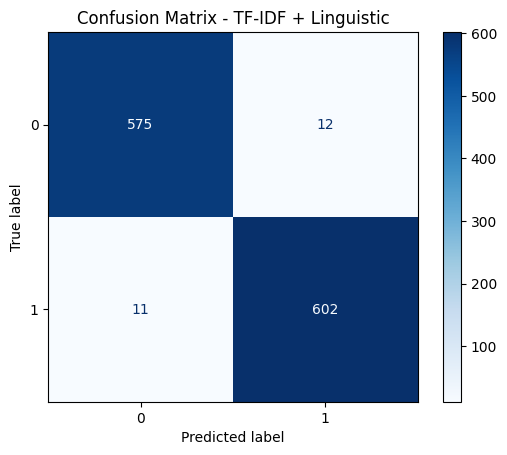

In [21]:
cm_combined = confusion_matrix(y_test, y_pred_combined)
print("Confusion Matrix (Combined Model):")
ConfusionMatrixDisplay(cm_combined).plot(cmap='Blues')
plt.title("Confusion Matrix - TF-IDF + Linguistic")
plt.show()

Confusion Matrix (TF-IDF Only):


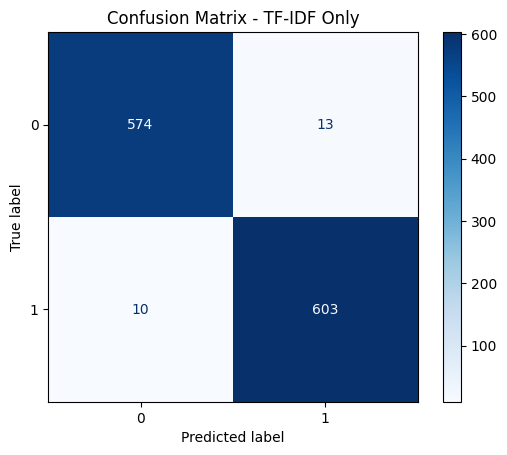

In [22]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm2 = confusion_matrix(y_test2, y_pred2)
print("Confusion Matrix (TF-IDF Only):")
ConfusionMatrixDisplay(cm2).plot(cmap='Blues')
plt.title("Confusion Matrix - TF-IDF Only")
plt.show()

**COMPARISON**

In [23]:
acc_tfidf = model2.score(X_test2, y_test2)
acc_combined = model.score(X_test, y_test)
print("TF-IDF Only Accuracy:", acc_tfidf)
print("Combined Model Accuracy:", acc_combined)

TF-IDF Only Accuracy: 0.9808333333333333
Combined Model Accuracy: 0.9808333333333333


In [24]:
from sklearn.metrics import precision_score, recall_score, f1_score

comparison = {
    "Model": ["TF-IDF Only", "TF-IDF + Linguistic"],
    "Accuracy": [
        acc_tfidf,
        acc_combined
    ],
    "Precision": [
        precision_score(y_test2, y_pred2),
        precision_score(y_test, y_pred_combined)
    ],
    "Recall": [
        recall_score(y_test2, y_pred2),
        recall_score(y_test, y_pred_combined)
    ],
    "F1 Score": [
        f1_score(y_test2, y_pred2),
        f1_score(y_test, y_pred_combined)
    ]
}

comparison_df = pd.DataFrame(comparison)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,TF-IDF Only,0.980833,0.978896,0.983687,0.981286
1,TF-IDF + Linguistic,0.980833,0.980456,0.982055,0.981255


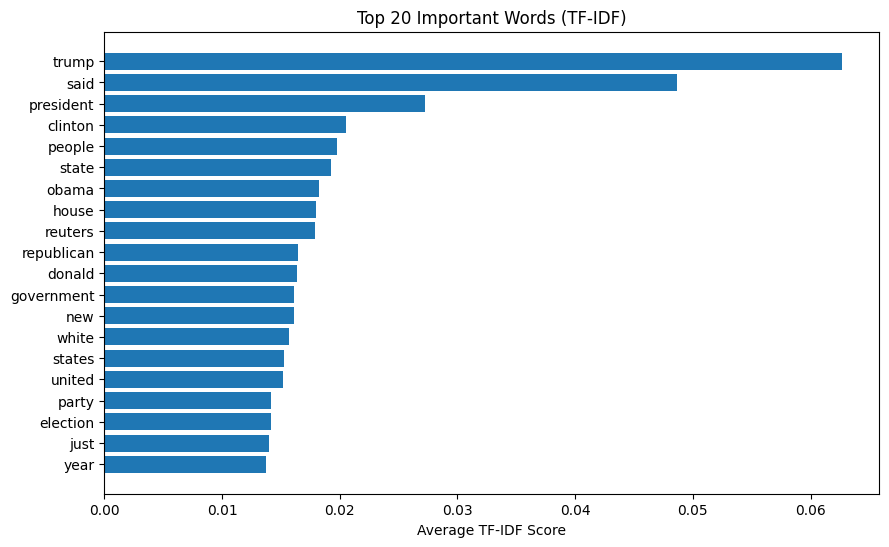

In [25]:
import numpy as np
import matplotlib.pyplot as plt
feature_names = np.array(tfidf.get_feature_names_out())
avg_tfidf = X_tfidf.mean(axis=0).A1
top_n = 20
top_indices = np.argsort(avg_tfidf)[-top_n:]
top_words = feature_names[top_indices]
top_scores = avg_tfidf[top_indices]
plt.figure(figsize=(10,6))
plt.barh(top_words, top_scores)
plt.xlabel("Average TF-IDF Score")
plt.title("Top 20 Important Words (TF-IDF)")
plt.show()

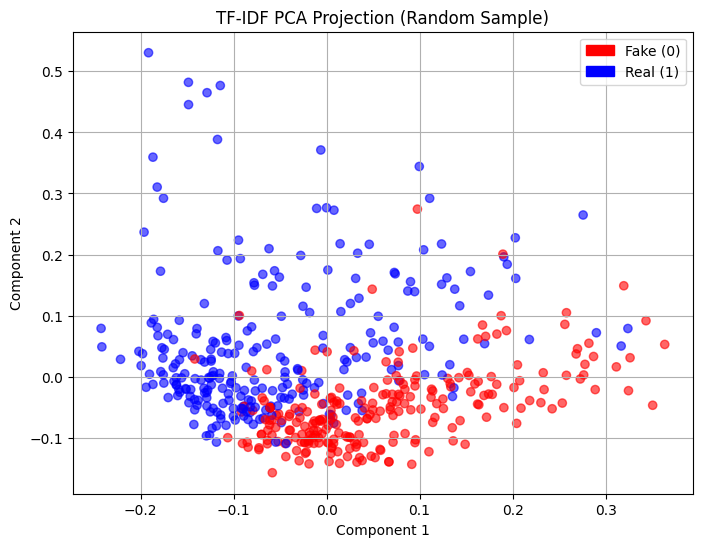

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
sample_size = 500
sample_indices = np.random.choice(len(df), sample_size, replace=False)
X_sample = X_tfidf[sample_indices].toarray()
y_sample = df["label"].iloc[sample_indices].values
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)
colors = ['red' if label == 0 else 'blue' for label in y_sample]

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=colors, alpha=0.6)

import matplotlib.patches as mpatches
plt.legend(handles=[
    mpatches.Patch(color='red', label='Fake (0)'),
    mpatches.Patch(color='blue', label='Real (1)')
])

plt.title("TF-IDF PCA Projection (Random Sample)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.grid(True)
plt.show()

In [27]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [28]:
def tree_depth(sentence):
    doc = nlp(sentence)
    depths = []

    for token in doc:
        depth = 0
        head = token
        while head.head != head:
            head = head.head
            depth += 1
        depths.append(depth)

    return max(depths) if depths else 0

In [29]:
real_sentences = (
    df[df.label==1]["sentences"]
    .explode()
    .dropna()
    .sample(50, random_state=42)
)

fake_sentences = (
    df[df.label==0]["sentences"]
    .explode()
    .dropna()
    .sample(50, random_state=42)
)

In [30]:
real_depths = [tree_depth(sent) for sent in real_sentences]
fake_depths = [tree_depth(sent) for sent in fake_sentences]

print("Average Tree Depth - Real:", sum(real_depths)/len(real_depths))
print("Average Tree Depth - Fake:", sum(fake_depths)/len(fake_depths))

Average Tree Depth - Real: 6.68
Average Tree Depth - Fake: 5.72


In [31]:
def adjective_count(pos_tags):
    return sum(1 for word, tag in pos_tags if tag in ["JJ","JJR","JJS"])

df["adj_count"] = df["pos_tags"].apply(adjective_count)

In [32]:
profile = df.groupby("label")[[
    "adj_count",
    "avg_sentence_length"
]].mean()

profile

,adj_count,avg_sentence_length
label,,
0,48.764667,33.727753
1,49.676000,31.070642


In [33]:
profile.index = ["Fake", "Real"]
profile

,adj_count,avg_sentence_length
Fake,48.764667,33.727753
Real,49.676000,31.070642


In [34]:
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X_combined,
    df["label"],
    df.index,        
    test_size=0.2,
    random_state=42
)

In [35]:
y_pred_combined = model.predict(X_test)

In [36]:
results = pd.DataFrame({
    "text": df.loc[idx_test, "text"].values,
    "true": y_test.values,
    "pred": y_pred_combined
})

In [37]:
misclassified_real = results[
    (results["true"] == 1) &
    (results["pred"] == 0)
]

misclassified_real.head(1)

,text,true,pred
52,LIMA (Reuters) - U.S. President Barack Obama d...,1,0


In [38]:
print(misclassified_real.iloc[0]["text"])

LIMA (Reuters) - U.S. President Barack Obama did in Latin America what he tried to do in Europe: tell worried citizens not to draw negative conclusions about the man he once called unfit to serve in the White House, President-elect Donald Trump. In the last stop of an international farewell tour that included visits to Greece and Germany, Obama continued his efforts to calm anxieties since Republican businessman Trump beat Democratic rival and former Secretary of State Hillary Clinton in the U.S. presidential race. “My main message to you ... and the message I delivered in Europe is don’t just assume the worst,” Obama told a group of young people during a question-and-answer session in Peru on Saturday. “Wait until the administration is in place, it’s actually putting its policies together, and then you can make your judgments as to whether or not it’s consistent with the international community’s interest in living in peace and prosperity together.” Trump won the election after promis